# BE 521: Final Project Part 1
Spring 2025

Adapted by Kevin Xie

Updated by Zhongchuan Xu

32 Points

Objective: Predict finger movements from ECoG Recordings

Due: April 10th


# Project Overview

This final project involves predicting finger flexion using intracranial EEG (ECoG) in three human subjects. The data and problem framing come from the 4th BCI Competition (Miller et al. 2008). For the details of the problem, experimental protocol, data, and evaluation, please see the original 4th BCI Competition documentation (included as separate document). The remainder of the current document details your deliverables for part 1 of the project.


## Important Deadlines
* Final Project Part 1 (Canvas)
 * Due: April 10th
 * 32 Points
* Team Registration
 * Due: April 10th
 * 5 Points
* Team Responsibilities (Canvas)
 * Due: April 14th
 * 3 Point
* Checkpoint 1, r > 0.33
 * Due: April 17th
 * 20 Points
* Checkpoint 2, r > 0.45
 * Due: April 24th
 * 15 Points
* End of competition, submit algorithm (Canvas):
 * Due: April 25th
 * 15 Points
* Final Report
 * Due: April 27th
 * 60 Points
* Competition results (Final class session)
 * On: April 30th

The grading is structured so that going the extra mile is definitely rewarded. We want you to show what you've learned this semester, and to have some fun!

## Writing Your Code
To get started with the final project we have provided a a series of method stubs for you to fill out. Your job for part 1 of the final project is to build a prediction pipeline that takes in the ECoG and dataglove finger angle recordings (serving as the data and labels respectively), then uses machine learning methods to generate predicted finger angles from the ECoG signals. The functions you will develop in this assignment are as follows:
* `get_windowed_feats` This function will take in raw ECoG data, and use the 2 following helper functions to filter the data, calculate sliding-window features.
 * `filter_data` This function will apply a filter to the raw data and return cleaned data
 * `get_features` This function will take in a window of cleaned data and return a vector of features for that window
* `create_R_matrix` This function will take in a feature matrix and return a response matrix as an adaptation of the optimal linear decoder method.




## Optimal Linear Decoder
You will use a modified version of the **optimal linear decoder** method as described in Warland et al., 1997. We will recapitulate the method in this section, but consult the paper for more details. Our ultimate goal is to predict the angle of each finger as it moves over time using data recorded from the ECoG channels.

The position data is captured for 300 seconds, which you will split up into $M$ total time bins, and the number of ECoG channels, $\nu$, is 61, 46, and 64 for subject 1, 2, and 3 respectively.

The paradigm we adapt here tries to predict finger angle at a given time window using ECoG features calculated over the preceding $N$ time windows, using
the following steps:

First, $p$ features will be calculated across all $\nu$ ECoG channels over $M$ total time windows to get a feature matrix of shape $\bigl(M, (\nu \times p)\bigr)$

Then, following the approach that Warland et al., 1997 takes, we will construct a row vector corresponding to each time bin, that contains features for all the ECoG channels over the preceding *N* time bins (in the paper, spike counts are their features and they index neurons instead of ECoG channels). Thus, there will be a good amount of redundancy between row vectors of adjacent time bins, but that is okay.

Let $r^{c,\phi}_t$ be the value of the feature in window $t \in \{1,2,\dots,M\}$, channel $c\in\{1,2,\dots,\nu\}$ and with feature $\phi\in\{1,2,\dots,p\}$. Let the response matrix $R \in \mathbb{R}^{M \times (1+N \cdot p \cdot \nu )}$ be defined as:

$$R = \begin{bmatrix}
\mathbf{1} & r^{(1,1)}_1 & r^{(1,1)}_1 & \cdots & r^{(1,1)}_1 & r^{(1,1)}_1 & r^{(1,2)}_1 & \cdots & r^{(1,2)}_1 & \cdots & r^{(\nu,p)}_1 & \cdots & r^{(\nu,p)}_1\\
\mathbf{1} & r^{(1,1)}_1 & r^{(1,1)}_1 & \cdots & r^{(1,1)}_1 & r^{(1,1)}_2 & r^{(1,2)}_1 & \cdots & r^{(1,2)}_2 & \cdots & r^{(\nu,p)}_1 & \cdots & r^{(\nu,p)}_2\\
\mathbf{1} & r^{(1,1)}_1 & r^{(1,1)}_1 & \cdots & r^{(1,1)}_2 & r^{(1,1)}_3 & r^{(1,2)}_1 & \cdots & r^{(1,2)}_3 & \cdots & r^{(\nu,p)}_1 & \cdots & r^{(\nu,p)}_3\\
\vdots   & \vdots     & \vdots     & \ddots & \vdots     & \vdots     & \vdots     & \ddots & \vdots   & \cdots & \vdots         & \ddots & \vdots\\
\mathbf{1} & r^{(1,1)}_1 & r^{(1,1)}_2 & \cdots & r^{(1,1)}_{N-1} & r^{(1,1)}_N & r^{(1,2)}_1 & \cdots & r^{(1,2)}_N & \cdots & r^{(\nu,p)}_1 & \cdots & r^{(\nu,p)}_N\\
\mathbf{1} & r^{(1,1)}_2 & r^{(1,1)}_3 & \cdots &r^{(1,1)}_{N} & r^{(1,1)}_{N+1} & r^{(1,2)}_2 & \cdots & r^{(1,2)}_{N+1} & \cdots & r^{(\nu,p)}_2 & \cdots & r^{(\nu,p)}_{N+1}\\
\vdots   & \vdots     & \vdots     & \ddots & \vdots     & \vdots     & \vdots     & \ddots & \vdots   & \cdots & \vdots         & \ddots & \vdots\\
\mathbf{1} & r^{(1,1)}_{M-N+1} & r^{(1,1)}_{M-N+2} & \cdots & r^{(1,1)}_{M-1} & r^{(1,1)}_M & r^{(1,2)}_{M-N+1} & \cdots & r^{(1,2)}_M & \cdots & r^{(\nu,p)}_{M-N+1} & \cdots & r^{(\nu,p)}_M\\
\end{bmatrix}$$



This is also referred to as the design or feature matrix, with each column being a predictor, or feature. The column of 1’s accounts for the intercept term in linear regression/decoding. Here we are repeating the first windows $N-1$ times as the padding of the first windows. Make sure you understand what this matrix means before moving on.

We denote the target matrix as $Y \in \mathbb{R}^{M \times 5}$ and the prediction matrix (e.g. the predicted finger angles) as $\hat{Y} \in \mathbb{R}^{M \times 5}$. Note that in Warland et al., 1997, this quantity is referred to as the stimulus vector since they are talking about decoding the stimulus from neural data after it. We, on the other hand, are trying to decode finger positions using the ECoG data before it, but we can conveniently use the same method. Our goal is to find some optimal weight matrix or filter $f \in \mathbb{R}^{(1+N \cdot p \cdot \nu ) \times 5}$ that minimizes the mean squared error:

$$f^* = \operatorname{argmin}_{f} \, \mathcal{L}(f) = \operatorname{argmin}_{f} \left\|Y - \hat{Y}\right\|^2,$$
where $\hat{Y} = Rf$

We start with the mean squared error (MSE) loss function:
$$
\mathcal{L}(f) = \left\|Y - R\,f\right\|^2 = (Y - R\,f)^\top (Y - R\,f)
$$

To minimize the loss, we take the derivative with respect to the weight matrix $f$ and set it equal to zero:
$$
\frac{\partial \mathcal{L}}{\partial f} = -2\,R^\top (Y - R\,f) = 0
$$

This implies:
$$
R^\top Y = R^\top R\,f
$$

Assuming that $R^\top R$ is invertible, we solve for $f$:
$$
f = \left(R^\top R\right)^{-1} R^\top Y
$$

This is the the analytic form for the optimal filter $f$ that minimizes the MSE loss.

This equation should take a familiar form. Warland et al., 1997 don’t refer to it as such, but this is exactly the same as linear regression, one of the most commonly used algorithms in practical machine learning. Not only is this algorithm remarkably powerful, but it has a beautiful analytic form for learning the “weights” (here, the $f$ matrix), a rarity in a field where almost all optimizations involve some sort of iterative algorithm. After learning the filter weights $f$, we can calculate the optimal predictions as: $$\hat{Y} = Rf$$

## Dataset
The dataset for part 1 is stored within `final_proj_part1_data.pkl`. The `.pkl` file type is a pickle file, which stores python objects. You can open the `.pkl` file with this code.
```
with open('final_proj_part1_data.pkl', 'rb') as f:
  proj_data = pickle.load(f)
```
This stores the data inside the file as a variable named proj_data.

**NOTE: Python versions don't pickle with each other very well. This pickle file was made in Google Colab. If you are running your own installation of Python and cannot load the file, we recommend you use Colab**

There are 3 subjects, each with their own Data Glove data (the glove they used to capture hand movements), and ECoG data. The data is represented as a dictionary with keys `'data_glove'` and `'ecog'`, storing the data glove and ecog data, respectively. These keys map to python lists of 3 items. Each item is an np.ndarray corresponding to a subject's data. See the pseudcode below.

```
proj_data = {
  'data_glove':[np.ndarray for subject 1, np.ndarray for subject 2, np.ndarray for subject 3],
  'ecog':[np.ndarray for subject 1, np.ndarray for subject 2, np.ndarray for subject 3]
}
```

All np.ndarray shapes for `'data_glove'` should be $(T,5)$, where $T$ is the number of samples in the signal, and 5 is the number of fingers.

The np.ndarray shapes for `'ecog'` are $(T, 61)$, $(T, 46)$, and $(T,64)$, where T is the number of samples in the signal, and each subject had 61, 46, and 64 ecog channels, respectively.

**The sampling rate of the data glove and ecog was 1000 Hz**

<!-- The dataset is also on IEEG
* Subject 1
 * I521_Sub1_Training_ecog - Training ECoG \
 * I521_Sub1_Training_dg - Training Data Glove \
 * I521_Sub1_Leaderboard_ecog - Testing ECoG
* Subject 2
 * I521_Sub2_Training_ecog - Training ECoG \
 * I521_Sub2_Training_dg - Training Data Glove \
 * I521_Sub2_Leaderboard_ecog - Testing ECoG
* Subject 3
 * I521_Sub3_Training_ecog - Training ECoG \
 * I521_Sub3_Training_dg - Training Data Glove \
 * I521_Sub3_Leaderboard_ecog - Testing ECoG -->

Your task is to develop an algorithm to use the ECoG to predict finger movements that are captured by the Data Glove.

# 1. Getting Started (4 pts)
The following sections will walk you through the development of the prediction pipeline.

In [ ]:
!jupyter nbconvert --to html Dhyey_FinalProject_1.ipynb

In [2]:
#Set up the notebook environment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from scipy.stats import pearsonr
from scipy import signal as sig

## 1.
Extract the dataglove and ECoG data for each subject from the pickle file. Feel free to copy the code snippet above. Split the data into a training and testing set (at least 50% of the data should be in the training set).

**How many samples are there in the full ECoG recording (before splitting)?** (1 pt)

**How many samples do you have in your training set? In your testing set?** (1 pt)

In [102]:
#Your code here

#Loading Pickle File
with open('final_proj_part1_data.pkl', 'rb') as f:
  proj_data = pickle.load(f)

print(proj_data.keys())
# Number of samples for Subject 1 in ECoG data -
proj_data['ecog'][0].shape

dict_keys(['data_glove', 'ecog'])


(300000, 61)

In [104]:

ecog_data = proj_data['ecog']
dataglove_data = proj_data['data_glove']

train_ratio = 0.8

# Looping through each subject
for subject_index in range(3):
    ecog_subject_data = ecog_data[subject_index]
    dataglove_subject_data = dataglove_data[subject_index]
    split_index = int(len(ecog_subject_data) * train_ratio)
    ecog_train = ecog_subject_data[:split_index, :]
    ecog_test = ecog_subject_data[split_index:, :]
    dataglove_train = dataglove_subject_data[:split_index, :]
    dataglove_test = dataglove_subject_data[split_index:, :]

# Printing samples
for subject_index in range(3):
    num_samples = len(ecog_data[subject_index])
    print(f"Subject {subject_index + 1}: {num_samples} samples")


for subject_index in range(3):
    num_train_samples = len(ecog_train)
    num_test_samples = len(ecog_test)
    print(f"Subject {subject_index + 1}: Training - {num_train_samples} samples, Testing - {num_test_samples} samples")

Subject 1: 300000 samples
Subject 2: 300000 samples
Subject 3: 300000 samples
Subject 1: Training - 240000 samples, Testing - 60000 samples
Subject 2: Training - 240000 samples, Testing - 60000 samples
Subject 3: Training - 240000 samples, Testing - 60000 samples


Your answer here

## 2.
Next, complete the `filter_data` function. Test it using the raw data extracted in the prior step. What filter types and cutoff frequencies did you use? (2 pts)

In [108]:
def filter_data(raw_eeg, fs=1000):
  """
  Write a filter function to clean underlying data.
  Filter type and parameters are up to you. Points will be awarded for reasonable filter type, parameters and application.
  Please note there are many acceptable answers, but make sure you aren't throwing out crucial data or adversly
  distorting the underlying data!

  Input:
    raw_eeg (samples x channels): the raw signal
    fs: the sampling rate (1000 for this dataset)
  Output:
    clean_data (samples x channels): the filtered signal
  """

  #n_samples, n_channels = raw_eeg.shape

  #print(n_channels)

  # Bandpass filter for freq between 1-120 Hz -
  # Lower cutoff frequency
  lowcut = 5.0
  # Upper cutoff frequency
  highcut = 130.0
  # Nyquist freq
  nyquist = fs / 2

  low = lowcut / nyquist
  high = highcut / nyquist


  # Butterworth bandpass filter of 4th order -
  b_band, a_band = sig.butter(4, [low, high], btype='band')

  # Additional Notch filter for 60 Hz power line noise -
  # Notch frequency
  fn = 60.0
  # Quality factor
  Q = 30.0

  b_notch, a_notch = sig.iirnotch(fn/(nyquist), Q)

  # Initializing output array
  clean_data = np.zeros_like(raw_eeg)

  # Applying both filters to each channel of raw_eeg data



  # Applying bandpass filter
  eeg_b = sig.filtfilt(b_band, a_band, raw_eeg)
  # Applying notch filter
  clean_data = sig.filtfilt(b_notch, a_notch, eeg_b)

  return clean_data


In [109]:
#Your code here

raw_eeg_sub = ecog_data[0]
filtered_eeg_sub0 = filter_data(raw_eeg_sub)


print(filtered_eeg_sub0.shape)
print(filtered_eeg_sub0)

print("The filter types I used were Bandpass filter for frquencies between 5-130 Hz, and a Notch filter of 60Hz")

(300000, 61)
[[ -776.94510608 -1308.39226625 -1566.38209095 ...  1002.45753039
    661.67627243   -69.42640025]
 [ -689.35410313 -1261.56154841 -1565.00740678 ...   997.61127601
    652.73682199   -87.89246181]
 [ -625.73003549 -1274.39666383 -1643.14095866 ...  1055.39079883
    686.53218382   -89.1042542 ]
 ...
 [  -87.79432958  -294.10089238  -632.62512106 ...  3041.28433279
   1968.82088743   660.62694364]
 [ -187.72138459  -568.4813086  -1038.87301937 ...  2948.87947065
   1947.87754759   721.95779347]
 [ -265.32661771  -833.20075025 -1447.5695077  ...  2869.26978302
   1936.85899588   787.91605731]]
The filter types I used were Bandpass filter for frquencies between 5-130 Hz, and a Notch filter of 60Hz


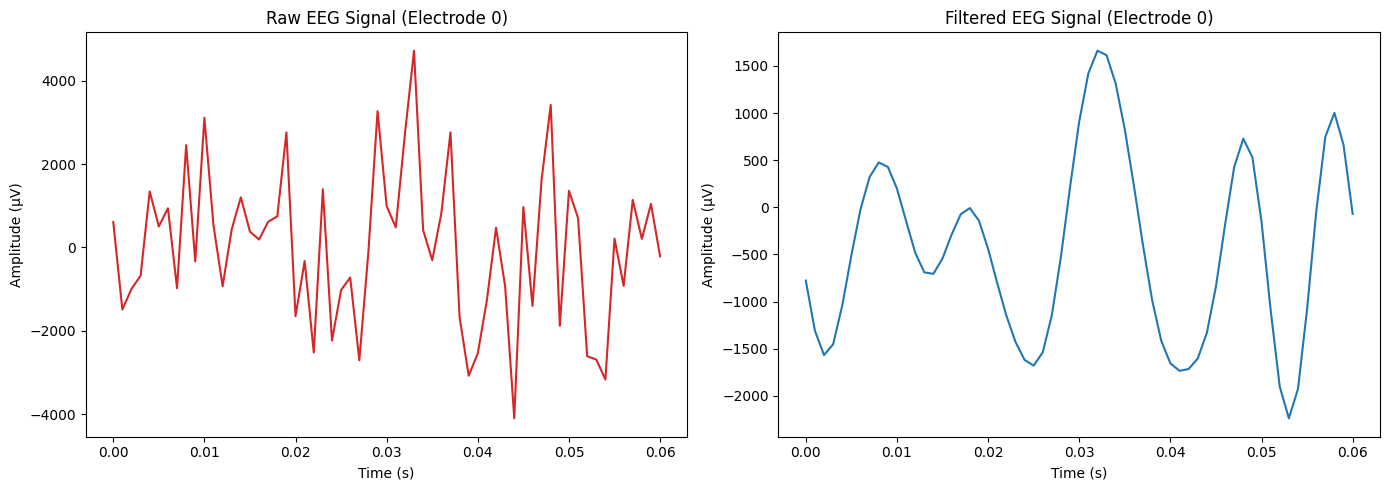

In [110]:
import matplotlib.pyplot as plt


electrode_idx = 0
available_samples = raw_eeg_sub.shape[1]

# Defining a time window to visualize
time_window = min(1000, available_samples)

# Extracting the segment from raw and filtered
raw_segment = raw_eeg_sub[electrode_idx, :time_window]
filtered_segment = filtered_eeg_sub0[electrode_idx, :time_window]


sampling_rate = 1000  # Hz
time = np.arange(time_window) / sampling_rate


###
# Plotting
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(time, raw_segment, label="Raw EEG", color="tab:red")
plt.title("Raw EEG Signal (Electrode 0)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")

plt.subplot(1, 2, 2)
plt.plot(time, filtered_segment, label="Filtered EEG", color="tab:blue")
plt.title("Filtered EEG Signal (Electrode 0)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")


plt.tight_layout()
plt.show()


Your answer here

# 2. Calculating Features (12 points)

Here you will complete the `get_windowed_feats` and `get_features` functions.

## 1.
We will calculate features across sliding time windows. if we use a suggested window length of 100ms with a 50ms window overlap, how many feature windows, $M$, will we have if we computed features using all the data in a given subject? Feel free to re-use code from previous homeworks.

In [111]:
#Your code here

# Parameters
total_samples = 300000
fs = 1000
window_length_ms = 100
overlap_ms = 50

# Converting to samples
window_samples = int(window_length_ms * fs / 1000)
step_samples = int((window_length_ms - overlap_ms) * fs / 1000)

# Calculating number of windows
M = (total_samples - window_samples) // step_samples + 1

print(f"Number of feature windows M: {M}")

Number of feature windows M: 5999


Your answer here

## 2.
Now complete the `get_features` function. Please create **4 or more** different features to calculate for each channel in each time window. Features may include the average time-domain voltage, or the average frequency-domain magnitude in consecutive 15Hz frequency bands, bandpower of relevant frequency bands, etc...

In [112]:
def get_features(filtered_window, fs=1000):
  """
    Write a function that calculates features for a given filtered window.
    Feel free to use features you have seen before in this class, features that
    have been used in the literature, or design your own!

    Input:
      filtered_window (window_samples x channels): the window of the filtered ecog signal
      fs: sampling rate
    Output:
      features (channels x num_features): the features calculated on each channel for the window
  """


  # Dimensions

  window_samples, n_channels = filtered_window.shape


  # Mean amplitude, variance, 4 bandpowers
  num_features = 6
  features = np.zeros((n_channels, num_features))

  # Mean Amplitude = average time domain voltage
  features[:, 0] = np.mean(filtered_window, axis=0)

  # Variance = power in time domain
  features[:, 1] = np.var(filtered_window, axis=0)

  # Computing power spectral density using Welch's method
  f, psd = sig.welch(filtered_window, fs=fs, nperseg=window_samples, axis=0)


  # Defining frequency bands of interest in Hz acc to HW doc
  bands = {
      'delta_theta': (5, 15),
      'alpha_beta': (20, 25),
      'low_gamma': (75, 115),
      'high_gamma': (125, 160)
  }

  # Bandpower in four frequency bands
  for i, (band_name, (fmin, fmax)) in enumerate(bands.items(), start=2):
      # frequency indices corresponding to the band
      idx_band = np.logical_and(f >= fmin, f <= fmax)
      # Integrating PSD over the frequency band
      band_power = np.mean(psd[idx_band, :], axis=0)
      features[:, i] = band_power

  return features

In [113]:
get_features(filtered_eeg_sub0)

array([[-1.34861342e-01,  2.04659778e+05,  4.50852623e+03,
         1.33547987e+03,  1.83544310e+01,  3.66880264e+00],
       [-6.68546310e-02,  1.14283110e+06,  2.74896928e+04,
         9.13109838e+03,  2.12305258e+02,  4.69712731e+01],
       [-2.21866601e-01,  3.32579415e+06,  7.95845735e+04,
         2.63063839e+04,  6.06830641e+02,  1.36106177e+02],
       [-6.18600899e-01,  4.68097178e+06,  1.16520350e+05,
         3.78048657e+04,  8.72912125e+02,  1.96652269e+02],
       [-1.05062922e+00,  4.64190564e+06,  1.23705234e+05,
         3.83803145e+04,  8.89084637e+02,  2.00462387e+02],
       [-1.22236854e+00,  3.93904498e+06,  1.13018998e+05,
         3.31026673e+04,  7.63431295e+02,  1.71567334e+02],
       [-9.53753894e-01,  3.27789606e+06,  9.93748015e+04,
         2.78233046e+04,  6.34029845e+02,  1.41436020e+02],
       [-3.14168786e-01,  2.99127903e+06,  9.47624532e+04,
         2.46464052e+04,  5.56976055e+02,  1.23095897e+02],
       [ 3.95928361e-01,  3.12211824e+06,  1.046

## 3.
Now finish the `get_windowed_feats` function by putting the `filter_data` and `get_features` functions together to return a feature vector for each time window.

In [114]:
import numpy as np

def get_windowed_feats(raw_ecog, fs, window_length, window_overlap):
    """
    Processes data through filtering and feature calculation, returning features for each time window.

    Inputs:
      raw_ecog (samples x channels): the raw signal
      fs: the sampling rate (1000 for this dataset)
      window_length: the window's length (in ms)
      window_overlap: the window's overlap (in ms)
    Output:
      all_feats (num_windows x (channels x features)): the features for each channel for each time window
    """

    # Filtering the entire signal
    filtered_full_ecog = filter_data(raw_ecog, fs)

    # Converting window length and overlap from ms to samples
    window_samples = int(window_length * fs / 1000)
    overlap_samples = int(window_overlap * fs / 1000)
    step_samples = window_samples - overlap_samples

    num_samples, num_channels = filtered_full_ecog.shape

    # Calculating number of windows
    num_windows = (num_samples - window_samples) // step_samples + 1
    if num_windows <= 0:
        print("Error")

    # Defining number of features per channel
    num_features = 6
    all_feats = np.zeros((num_windows, num_channels * num_features))

    # Extracting features for each window
    for window_index in range(num_windows):
        start_sample = window_index * step_samples
        end_sample = start_sample + window_samples
        window_data = filtered_full_ecog[start_sample:end_sample, :]
        window_features = get_features(window_data, fs)
        all_feats[window_index, :] = window_features.flatten()

    return all_feats

# 3. Creating the Response Matrix (6 points)
In this section, you will develop code for your *create_R_matrix* function

## 1.
For our set of 62 channels in subject 1, what would the dimensions of the $R$ matrix be if we calculated 6 different feature types per channel, and $N = 3$ time bins where the number of total time bins $M$ is the number you calculated in 2.1? (1pt)

In [115]:
M

5999

In [116]:
#Your code here

N = 3
channels = 62
feats_p = 6

# Dimension of R matrix = M x (1+N*channels*feats_p)
dim2 = 1 + (N * channels * feats_p)
print(f"Dimensions of R matrix: {M} x {dim2}")

Dimensions of R matrix: 5999 x 1117


Your answer here

## 2.
We do not have feature data to fill out the first $N-1$ data rows in the R matrix that will be used to predict the first $N-1$ finger angles. One way to work around this is to append a copy of the first rows $N-1$ times of your feature matrix to the beginning of your feature matrix before calculating R. Make this adjustment in `create_R_matrix`, then compute the response matrix R. You can test whether your function is running correctly by running `create_R_matrix` with data from `testRfunction.pkl` using 3 windows and verifying that the quantity `np.mean(R)` is 25.4669 (5 points).

In [118]:
import numpy as np

def create_R_matrix(features, N_wind):
    """
    Calculate the R matrix.

    Input:
      features (num_windows x (channels x features)): features from get_windowed_feats
      N_wind: number of windows to use in the R matrix
    Output:
      R (samples x (1 + N_wind * channels * features))
    """

    M, total_features = features.shape
    N = N_wind

    # Initializing R matrix
    R = np.zeros((M, 1 + N * total_features))

    # Padding the feature matrix with N-1 copies of the first row
    padding = np.tile(features[0, :], (N-1, 1))
    padded_features = np.vstack([padding, features])


    #######

    # Adding the intercept column
    R[:, 0] = 1
    for t in range(M):
        start_idx = t
        end_idx = t + N
        window_features = padded_features[start_idx:end_idx, :]
        R[t, 1:] = window_features.flatten()

    return R

In [119]:
#Your code here

#Loading Pickle File
with open('testRfunction.pkl', 'rb') as f:
  test_data = pickle.load(f)



# Assume test_data contains a feature matrix; run with N=3
R_test = create_R_matrix(test_data, 3)
mean_R = np.mean(R_test)
print(f"Mean of R matrix: {R_test}")
print(f"Mean of R matrix: {mean_R:.4f}")

test_data[0]

Mean of R matrix: [[ 1. 17. 22. ...  3. 33. 11.]
 [ 1. 17. 22. ...  6.  3. 47.]
 [ 1. 17. 22. ... 30. 23. 41.]
 ...
 [ 1.  9. 39. ...  1. 26. 27.]
 [ 1. 19. 43. ...  8.  5. 12.]
 [ 1.  2. 46. ... 11. 34. 45.]]
Mean of R matrix: 25.4669


array([17, 22, 27, 41, 46, 48, 41, 29, 20, 41, 19, 22, 34, 20, 32, 41, 41,
       19, 28, 36, 34, 37, 43, 34, 43, 35, 15, 13,  5, 22, 50, 27, 35, 26,
       47, 19, 41,  1,  6, 43, 24, 33, 26, 21,  5, 42, 50, 28, 32, 23,  3,
       43, 48, 26, 50, 26, 23, 35, 33, 45,  6,  6,  5, 15,  4, 31, 48, 38,
        4, 13, 22, 30, 45, 46, 17, 50,  3, 16, 30,  3, 23, 42, 50,  4, 25,
       12, 12,  6,  8, 11, 16,  7, 41, 34, 31, 13, 26,  5, 19, 43, 45, 15,
       10, 15, 40,  9, 42, 40,  1, 32,  8, 19, 34, 50, 49, 34, 28, 39, 37,
       37, 11, 22, 34,  6, 24, 39, 50, 17, 41, 21, 36, 11, 27,  6, 40, 48,
       41, 21, 21, 49,  3, 11, 46, 20, 14, 32, 23, 27,  1, 29, 47,  6, 23,
       45, 20, 43, 19, 36, 14,  4, 15, 43,  3,  6, 30,  4, 41, 21, 30, 17,
       17, 20, 48, 40, 37, 14,  6,  9, 31,  6, 30, 10, 16, 48, 46, 22,  3,
       12, 14, 14, 42, 33, 49, 36, 14, 28, 45,  5, 20,  3, 37, 31, 14, 24,
       11, 38, 45,  5, 21, 45,  1, 28, 13, 23, 36, 19, 20, 19,  2, 14, 23,
       15, 38, 39, 37,  9

Your answer here

# 4. ML Training and Testing (10 points)
Here we will use the optimal linear decoder framework to predict finger angles, and additionally you will use one or more models of your own choosing to make the prediction.

NOTE: This is a regression task - we are asking you to predict the movement of each finger for each subject.

## 1.

Calculate the linear filter $f$ as defined above for all 5 finger angles using features calculated from your training data. You will have to first down-sample the finger flexion data so that your feature matrix, $R$, and your flexion data have the same number of time windows.

You will likely find [np.matmul](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html) or operator @, and [np.linalg.inv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) to be useful.

In [120]:

fs = 1000
window_length_ms = 200
overlap_ms = 100
N_wind = 3

# Extracting features
train_features = get_windowed_feats(ecog_train, fs, window_length_ms, overlap_ms)
print("train_features shape:", train_features.shape)


# Creating R matrix
R_train = create_R_matrix(train_features, N_wind)
print("R_train shape:", R_train.shape)


# Downsampling dataglove data
num_windows_train = R_train.shape[0]
downsampling_factor = len(dataglove_train) // num_windows_train
dataglove_train_downsampled = dataglove_train[::downsampling_factor, :][:num_windows_train, :]
print("Downsampled glove data shape:", dataglove_train_downsampled.shape)

# Calculating linear filter (f)
f = np.linalg.inv(R_train.T @ R_train) @ (R_train.T @ dataglove_train_downsampled)
print("Shape of linear filter (f):", f.shape)
print(f)

train_features shape: (2399, 384)
R_train shape: (2399, 1153)
Downsampled glove data shape: (2399, 5)
Shape of linear filter (f): (1153, 5)
[[ 6.41770092e+00  3.35407074e+00  1.51616819e+00  4.61346477e+00
   1.88099257e+00]
 [ 2.32512315e+04  1.59553852e+04  5.05528394e+03  8.92799621e+03
   4.76375531e+03]
 [ 2.27566808e-04 -9.15644231e-05 -8.68346287e-05 -1.52181718e-04
  -1.12256065e-04]
 ...
 [-1.04715606e-04  1.42732441e-04 -1.40693030e-04 -6.90106224e-04
  -6.67378576e-04]
 [-1.26139524e-01  8.55122756e-02  1.11450680e-01  4.15708802e-02
   5.31290419e-02]
 [ 3.47788448e-01 -6.46280653e-01 -1.30609740e-01 -1.57711271e-03
  -4.74835642e-01]]


Your answer here

## 2.
Try one other machine learning models using your features and finger angle labels. Look back through previous homeworks to get some ideas

In [121]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Downsample dataglove data
num_windows_train = R_train.shape[0]
downsampling_factor = len(dataglove_train) // num_windows_train
dataglove_train_downsampled = dataglove_train[::downsampling_factor, :][:num_windows_train, :]
print("Downsampled glove data shape:", dataglove_train_downsampled.shape)

# 1. Calculate linear filter (f)
f = np.linalg.solve(R_train.T @ R_train, R_train.T @ dataglove_train_downsampled)  # More stable than inv
print("Shape of linear filter (f):", f.shape)

# Prediction with linear filter
y_pred_linear = R_train @ f
print("Linear filter predictions shape:", y_pred_linear.shape)

# 2. Random Forest Regressor
# Initializing the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training the model

ecog_train = ecog_subject_data[:split_index, :]
ecog_test = ecog_subject_data[split_index:, :]
dataglove_train = dataglove_subject_data[:split_index, :]
dataglove_test = dataglove_subject_data[split_index:, :]


rf_model.fit(train_features, dataglove_train_downsampled)

# Prediction with Random Forest
y_pred_rf = rf_model.predict(train_features)
print("Random Forest predictions shape:", y_pred_rf.shape)



# Evaluating both models on training data (for demonstration; use test data in practice)
mse_linear = mean_squared_error(dataglove_train_downsampled, y_pred_linear)
r2_linear = r2_score(dataglove_train_downsampled, y_pred_linear, multioutput='variance_weighted')
mse_rf = mean_squared_error(dataglove_train_downsampled, y_pred_rf)
r2_rf = r2_score(dataglove_train_downsampled, y_pred_rf, multioutput='variance_weighted')


print("\nPerformance on Training Data:")
print(f"Linear Filter - MSE: {mse_linear:.4f}, R^2: {r2_linear:.4f}")
print(f"Random Forest - MSE: {mse_rf:.4f}, R^2: {r2_rf:.4f}")

mse_linear = mean_squared_error(dataglove_train_downsampled, y_pred_linear)
r2_linear = r2_score(dataglove_train_downsampled, y_pred_linear, multioutput='variance_weighted')
mse_rf = mean_squared_error(dataglove_train_downsampled, y_pred_rf)
r2_rf = r2_score(dataglove_train_downsampled, y_pred_rf, multioutput='variance_weighted')


Downsampled glove data shape: (2399, 5)
Shape of linear filter (f): (1153, 5)
Linear filter predictions shape: (2399, 5)
Random Forest predictions shape: (2399, 5)

Performance on Training Data:
Linear Filter - MSE: 0.3928, R^2: 0.6018
Random Forest - MSE: 0.1254, R^2: 0.8729


Your answer here

## 3.
Produce predictions on the testing set for each finger angle.

Report your correlations here using the linear filter, and when using the other model(s) that you tried, as follows:

> For each subject, calculate the correlation coefficient between the predicted and test finger angles for each finger separately.

> You therefore should have 15 correlations: five per subject, with three subjects.

You will find  [pearsonr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) to be helpful and already imported.

Your answer here

In [122]:
from scipy.stats import pearsonr
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# Loading and spliting data = 70/30 split
ecog_data = proj_data['ecog']
dataglove_data = proj_data['data_glove']
train_ratio = 0.7
split_index = int(300000 * train_ratio)  # 210,000
ecog_train_list = [ecog_data[i][:split_index, :] for i in range(3)]
train_glove_list = [dataglove_data[i][:split_index, :] for i in range(3)]
ecog_test_list = [ecog_data[i][split_index:, :] for i in range(3)]
test_glove_list = [dataglove_data[i][split_index:, :] for i in range(3)]


fs = 1000
window_length_ms = 200
overlap_ms = 100
N_wind = 3

# Storing correlations
correlations_ridge = {i: [] for i in range(3)}
correlations_lgbm = {i: [] for i in range(3)}

for subject_index in range(3):
    print(f"\nProcessing Subject {subject_index + 1}")

    # Training data
    ecog_train = ecog_train_list[subject_index]
    train_glove = train_glove_list[subject_index]

    # Extracting training features
    train_features = get_windowed_feats(ecog_train, fs, window_length_ms, overlap_ms)
    print("train_features shape:", train_features.shape)

    # Creating R matrix
    R_train = create_R_matrix(train_features, N_wind)
    print("R_train shape:", R_train.shape)

    # Downsampling training glove data
    num_windows_train = R_train.shape[0]
    downsampling_factor = len(train_glove) // num_windows_train
    dataglove_train_downsampled = train_glove[::downsampling_factor, :][:num_windows_train, :]
    print("Downsampled train glove shape:", dataglove_train_downsampled.shape)

    # 1. Ridge Regression with MultiOutputRegressor
    ridge_base = Ridge(alpha=1.0, random_state=42)
    ridge_model = MultiOutputRegressor(ridge_base)
    ridge_model.fit(R_train, dataglove_train_downsampled)

    # 2. LightGBM Regressor with MultiOutputRegressor
    lgbm_base = lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    lgbm_model = MultiOutputRegressor(lgbm_base)
    lgbm_model.fit(train_features, dataglove_train_downsampled)



    ##############
    # Test data
    ecog_test = ecog_test_list[subject_index]
    test_glove = test_glove_list[subject_index]
    test_features = get_windowed_feats(ecog_test, fs, window_length_ms, overlap_ms)
    num_windows_test = test_features.shape[0]
    downsampling_factor_test = len(test_glove) // num_windows_test
    dataglove_test_downsampled = test_glove[::downsampling_factor_test, :][:num_windows_test, :]
    print("Downsampled test glove shape:", dataglove_test_downsampled.shape)

    # Test predictions
    R_test = create_R_matrix(test_features, N_wind)
    y_pred_ridge = ridge_model.predict(R_test)
    y_pred_lgbm = lgbm_model.predict(test_features)



    #############
    # Calculating correlations for each finger
    for finger in range(5):
        corr_ridge, _ = pearsonr(dataglove_test_downsampled[:, finger], y_pred_ridge[:, finger])
        correlations_ridge[subject_index].append(corr_ridge)

        corr_lgbm, _ = pearsonr(dataglove_test_downsampled[:, finger], y_pred_lgbm[:, finger])
        correlations_lgbm[subject_index].append(corr_lgbm)


# correlations
print("\nCorrelation Coefficients:")
print("Subject | Finger | Ridge Regression | LightGBM")
print("-" * 50)
for subject_index in range(3):
    for finger in range(5):
        print(f"Subject {subject_index + 1} | Finger {finger + 1} | "
              f"{correlations_ridge[subject_index][finger]:.4f} | "
              f"{correlations_lgbm[subject_index][finger]:.4f}")


Processing Subject 1
train_features shape: (2099, 366)
R_train shape: (2099, 1099)
Downsampled train glove shape: (2099, 5)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.90339e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.90339e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.90339e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.90339e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93330
[LightGBM] [Info] Number of data points in the train set: 2099, number of used features: 366
[LightGBM] [Info] Start training from score -0.090591


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 93330
[LightGBM] [Info] Number of data points in the train set: 2099, number of used features: 366
[LightGBM] [Info] Start training from score -0.062921


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 2099, number of used features: 384
[LightGBM] [Info] Start training from score 0.098255


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97920
[LightGBM] [Info] Number of data points in the train set: 2099, number of used features: 384
[LightGBM] [Info] Start training from score -0.160073
Downsampled test glove shape: (899, 5)

Correlation Coefficients:
Subject | Finger | Ridge Regression | LightGBM
--------------------------------------------------
Subject 1 | Finger 1 | 0.3484 | 0.2676
Subject 1 | Finger 2 | 0.5280 | 0.3435
Subject 1 | Finger 3 | 0.1907 | 0.1142
Subject 1 | Finger 4 | 0.3420 | 0.1955
Subject 1 | Finger 5 | 0.0778 | 0.0081
Subject 2 | Finger 1 | 0.2138 | 0.0596
Subject 2 | Finger 2 | 0.1116 | 0.0888
Subject 2 | Finger 3 | 0.1442 | 0.0766
Subject 2 | Finger 4 | 0.2043 | 0.0734
Subject 2 | Finger 5 | 0.0204 | -0.0333
Subject 3 | Finger 1 | 0.2630 | 0.0976
Subject 3 | Finger 2 | 0.1949 | 0.1500
Subject 3 | Finger 3 | 

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
